# Python Lesson 37: Binomial Distribution

**Concept page:** `wiki/concepts/binomial-distribution.md` · **Area:** probability

**You will be able to:**
- compute P(X=x)=C(n,x)p^x q^(n-x)
- check E(X)=np and Var=npq
- use logs to solve for n

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. The formula

In [2]:
from math import comb
def binom_pmf(n,p,x): return comb(n,x)*p**x*(1-p)**(n-x)
print(binom_pmf(4,2/3,2), 8/27)                 # Grade 12 advanced example
print(sum(binom_pmf(10,0.75,x) for x in range(6,11)))   # 0.9219

0.29629629629629634 0.2962962962962963
0.9218730926513672


## 2. Mean and variance

1.0000000000000002 4.500000000000002 4.5 2.4750000000000014 2.475


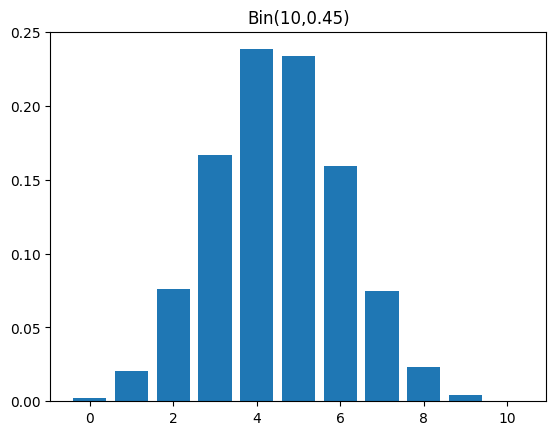

In [3]:
n,p=10,0.45; xs=np.arange(n+1); pm=np.array([binom_pmf(n,p,x) for x in xs])
print(pm.sum(), (xs*pm).sum(), n*p, ((xs-n*p)**2*pm).sum(), n*p*(1-p))
plt.bar(xs,pm); plt.title("Bin(10,0.45)"); plt.show()

## 3. Simulation

In [4]:
rng=np.random.default_rng(0); sim=rng.binomial(10,0.45,size=200000); print(np.bincount(sim)/len(sim))

[0.0026 0.0205 0.0772 0.1651 0.2408 0.2332 0.16   0.0735 0.0227 0.0041
 0.0004]


## 4. Solve P(X<1)=0.0256 for n with logs

In [5]:
print(np.log(0.0256)/np.log(0.4))

4.000000000000001


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 advanced p. 151–156 examples (8/27; 0.9219; n=4; most likely value near E(X)).

In [6]:
print(binom_pmf(4,2/3,2), sum(binom_pmf(10,0.75,x) for x in range(6,11)))

0.29629629629629634 0.9218730926513672


## Exercises

**Exercise 1.** A shooter hits with probability 0.2; probability of exactly 3 hits in 10 shots? (0.2013)

In [7]:
# your code here

**Exercise 2.** Given E(X)=2 and Var(X)=1.6 find n and p (10, 0.2).

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print(round(binom_pmf(10,0.2,3),4)); assert round(binom_pmf(10,0.2,3),4)==0.2013

0.2013


In [10]:
# Solution 2
q=1.6/2; p=1-q; n=2/p; print(n,p); assert round(n)==10 and abs(p-0.2)<1e-9

10.000000000000002 0.19999999999999996
